In [55]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


In [56]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
    calcular_apex_3d_gaia,
)
from src.sky_apex_plotter import plot_cluster_motion_geometry

In [57]:
# Cargar el CSV en un DataFrame y procesar directamente desde memoria.
data_path = project_root / "data" / "datos_resultados_modularizado" / "datos_clusterizados_todos_5d_f00_corr.csv"
df = pd.read_csv(data_path)
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc

nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["cluster_id"] = (
    df["grupo"].astype(str) + "_" + df["numeracion"].astype(str)
)
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["probabilidad"] = df["ConteoAgrupaciones"]/df["PresenteEnMuestras"]
df = df[df["ConteoAgrupaciones"]>0].copy()
df = df[df["cluster_id"]=="0_8"].copy()
# df["probabilidad"] = 1/(1-np.maximum(df["probabilidad"], 1e-5))

In [58]:
df["peso"] = df["probabilidad"]**10
df["group"] = "1"
# ahora vuelve a ejecutar la llamada
result = run_cluster_analysis_from_dataframe(
    df = df,
    cluster_id = "0_8",
    group_col = "grupo",
    division_ra_col = "coordenada_ra",
    division_dec_col = "coordenada_dec",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra_corrected",
    pmdec_col = "pmdec_corrected",
    parallax_col = "parallax_corrected",
    count_col = "ConteoAgrupaciones",
    present_col = "PresenteEnMuestras",
    cluster_col = "cluster_id",
    weight_col =  "peso",
    theta_clip_nsigma = 4.0
)
result.keys()

dict_keys(['data', 'cluster_result', 'summary'])

In [59]:
apex_radial = calcular_apex_3d_gaia(result["cluster_result"]['data_initial'],sigma_clip=5.0)

In [60]:
print("=" * 60)
print("RESULTADOS DEL ÁPEX DEL CÚMULO")
print("=" * 60)

print(f"Número de estrellas inicial   : {result['cluster_result']['n_stars_initial']}")
print(f"Número de estrellas           : {result['cluster_result']['n_stars_refined']}")

print("\n--- Ápex (ICRS) ---")
print(f"RA                            : {result['cluster_result']['apex_refined']['apex_ra_deg']:.6f} deg")
print(f"Dec                           : {result['cluster_result']['apex_refined']['apex_dec_deg']:.6f} deg")

print("\n--- Antápex (ICRS) ---")
print(f"RA                            : {result['cluster_result']['apex_refined']['antapex_ra_deg']:.6f} deg")
print(f"Dec                           : {result['cluster_result']['apex_refined']['antapex_dec_deg']:.6f} deg")

print("\n--- Dispersión angular ---")
print(f"RMS angular del ápex          : {result['cluster_result']['apex_refined']['rms_pole_residual_deg']:.4f} deg")

print("=" * 60)

RESULTADOS DEL ÁPEX DEL CÚMULO
Número de estrellas inicial   : 400
Número de estrellas           : 391

--- Ápex (ICRS) ---
RA                            : 92.896158 deg
Dec                           : 7.848135 deg

--- Antápex (ICRS) ---
RA                            : 272.896158 deg
Dec                           : -7.848135 deg

--- Dispersión angular ---
RMS angular del ápex          : 1.4265 deg


In [61]:
print("=" * 60)
print("RESULTADOS DEL ÁPEX DEL CÚMULO")
print("=" * 60)

print(f"Número de estrellas           : {apex_radial.n_stars}")

print("\n--- Ápex (ICRS) ---")
print(f"RA                            : {apex_radial.apex_ra_deg:.6f} deg")
print(f"Dec                           : {apex_radial.apex_dec_deg:.6f} deg")

print("\n--- Antápex (ICRS) ---")
print(f"RA                            : {apex_radial.antapex_ra_deg:.6f} deg")
print(f"Dec                           : {apex_radial.antapex_dec_deg:.6f} deg")

print("\n--- Velocidad media ---")
print(f"|V|                           : {apex_radial.speed_mean_kms:.3f} km/s")

print("\n--- Dispersión angular ---")
print(f"RMS angular del ápex          : {apex_radial.sigma_apex_rms_deg:.4f} deg")

print("=" * 60)

RESULTADOS DEL ÁPEX DEL CÚMULO
Número de estrellas           : 251

--- Ápex (ICRS) ---
RA                            : 97.641022 deg
Dec                           : 6.891512 deg

--- Antápex (ICRS) ---
RA                            : 277.641022 deg
Dec                           : -6.891512 deg

--- Velocidad media ---
|V|                           : 46.315 km/s

--- Dispersión angular ---
RMS angular del ápex          : 3.7745 deg


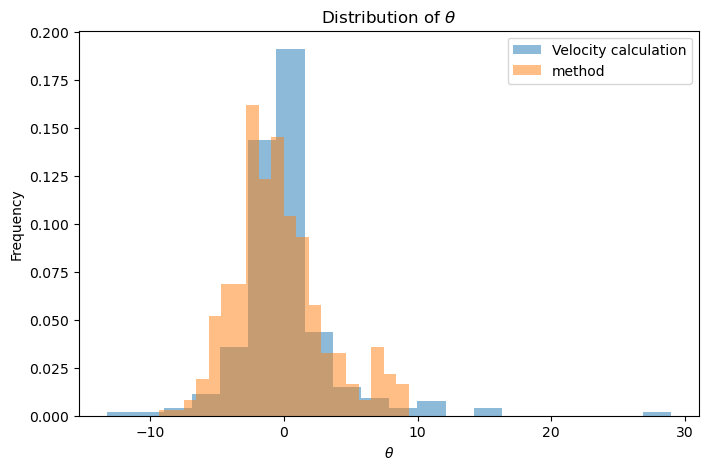

In [62]:
# Graficar
plt.figure(figsize=(8, 5))
plt.hist(apex_radial.stars["apex_angular_residual_signed_deg"], density=True, bins=20, alpha=0.5, label="Velocity calculation")
plt.hist(result["cluster_result"]["data_refined"]["pole_apex_error_direction_signed_initial_deg"], density=True, bins=20, alpha=0.5, label="method")
plt.xlabel(r"${\theta}$")
plt.ylabel("Frequency")
plt.title(r"Distribution of ${\theta}$")
plt.legend()


CLUSTER VALIDATION SUMMARY — ICRS / Gaia


,value
cluster_id,0_8
n_stars,400
n_stars_refined,391
fraction_kept,0.9775
apex_ra_deg,92.896158
apex_dec_deg,7.848135
antapex_ra_deg,272.896158
antapex_dec_deg,-7.848135
rms_pole_residual_deg,1.426534
median_pole_residual_deg,-0.332724



INTERPRETATION FLAGS
RMS pole residual          : 1.4265 deg
Median pole residual       : -0.3327 deg
Toward-apex fraction       : 1.0000
Fraction kept after filter : 0.9775
Apex-cross separation      : 0.1582 deg
Pole residuals             : ACCEPTABLE, but inspect outliers.
Motion orientation         : GOOD, most stars move toward the recovered apex.
Apex estimator agreement   : GOOD, eigen and pole-cross estimators agree.


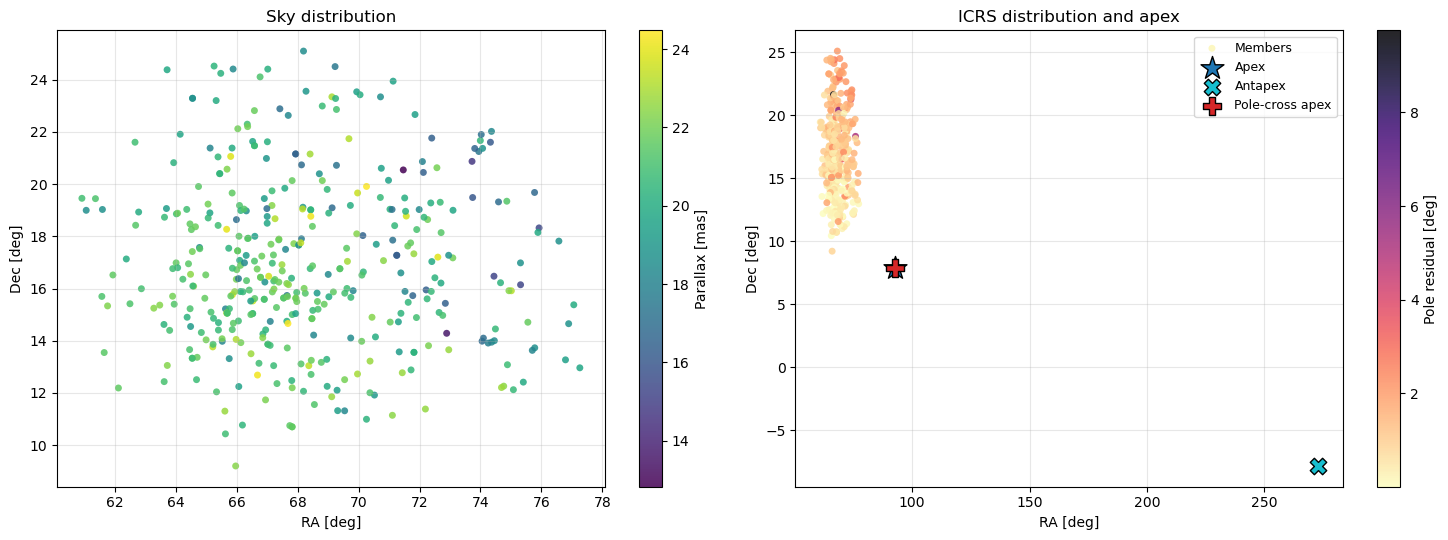

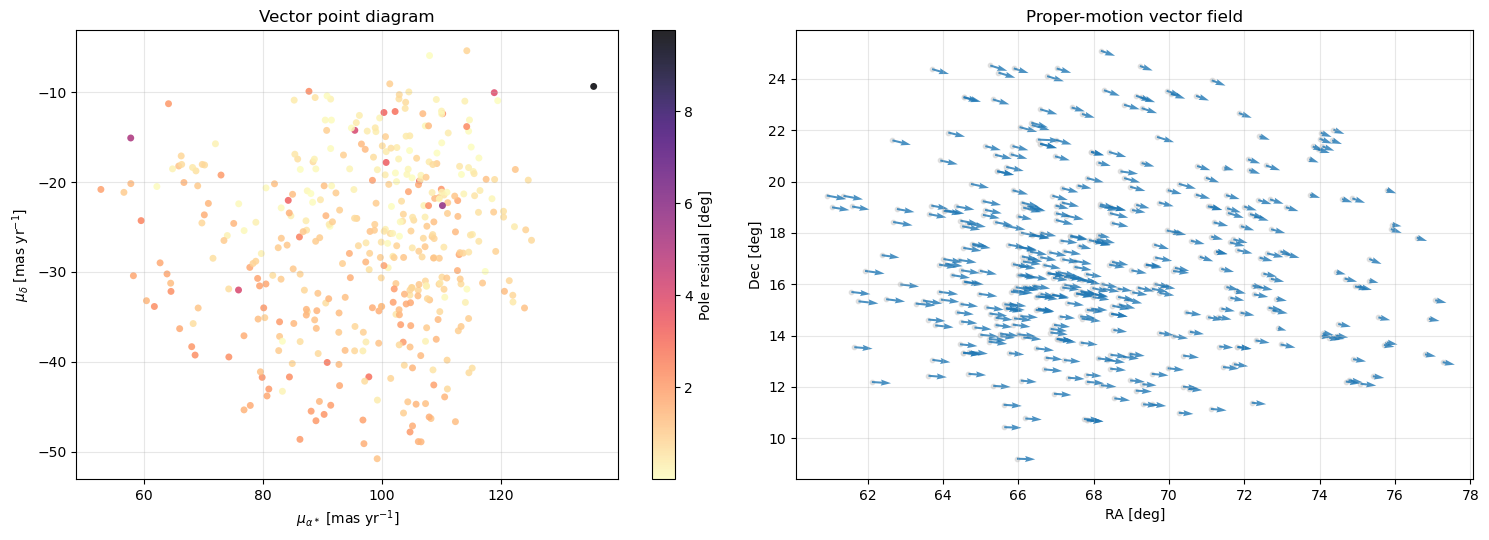

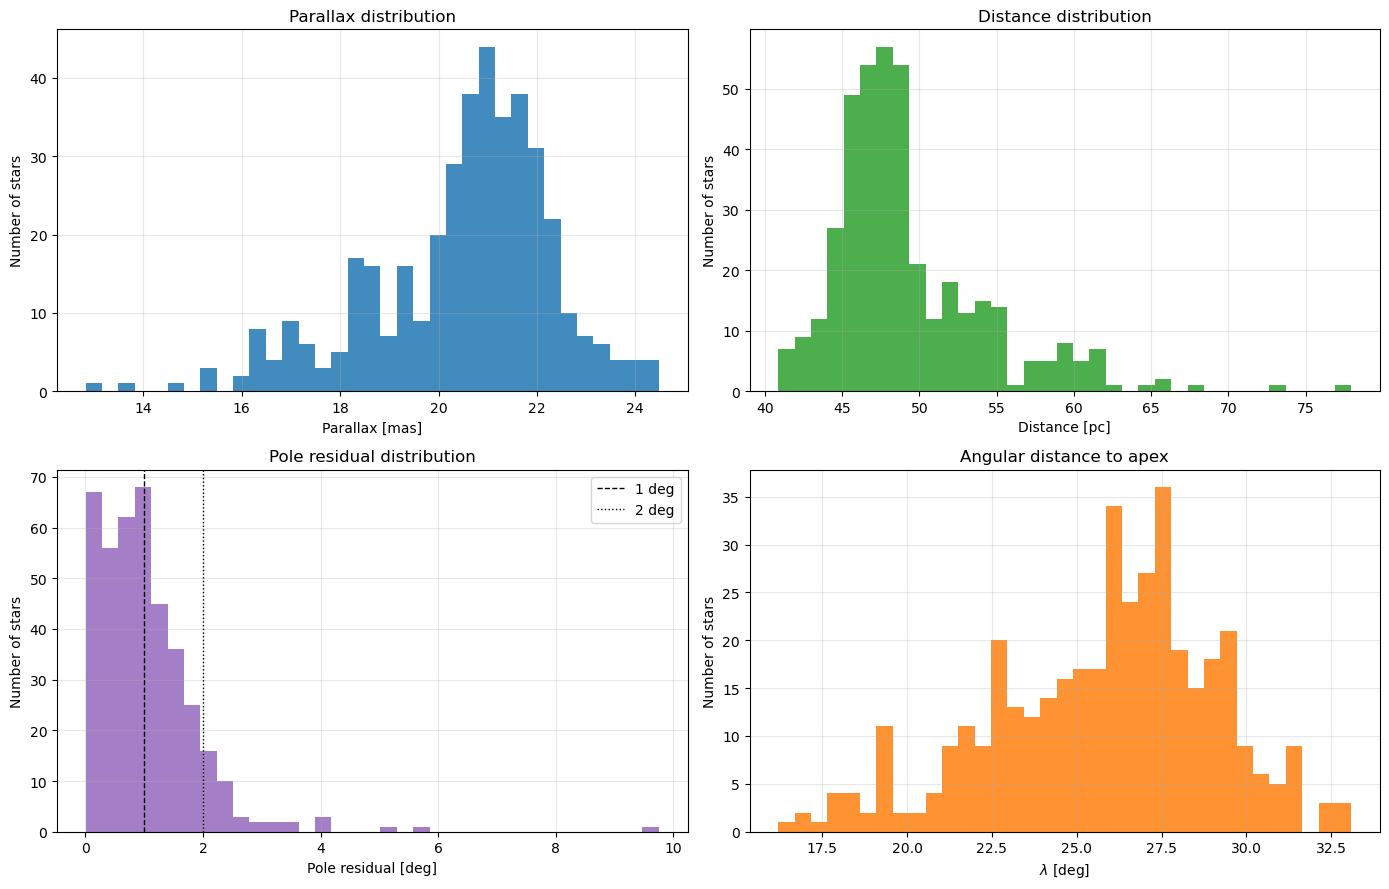

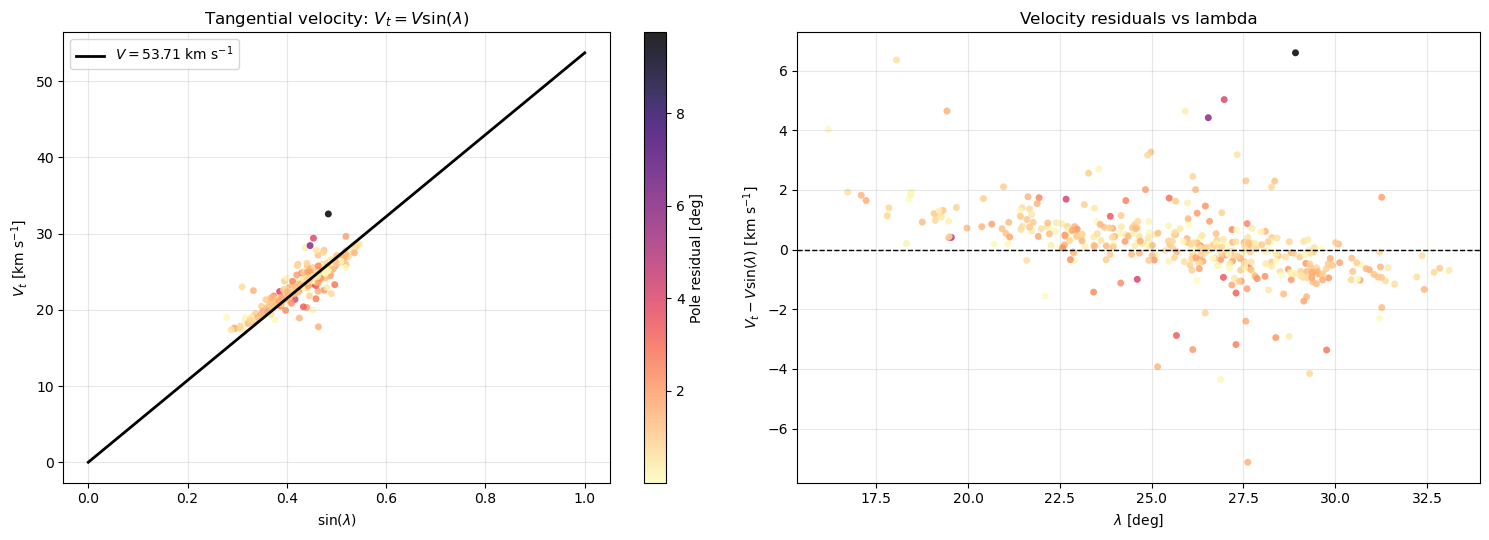

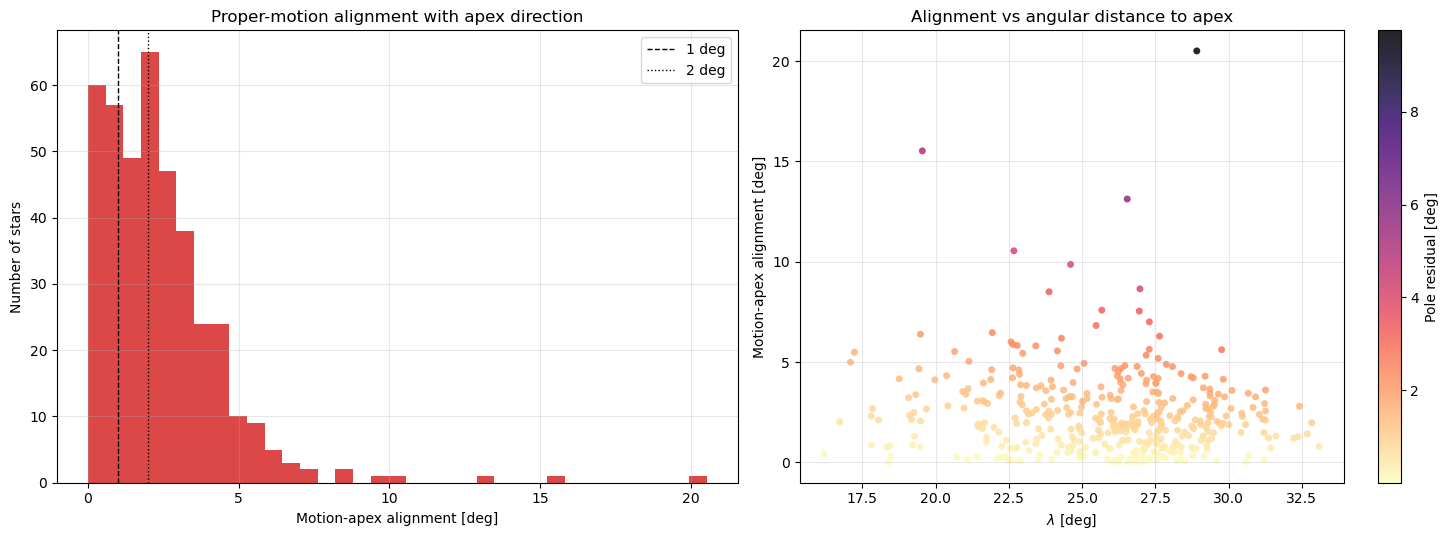

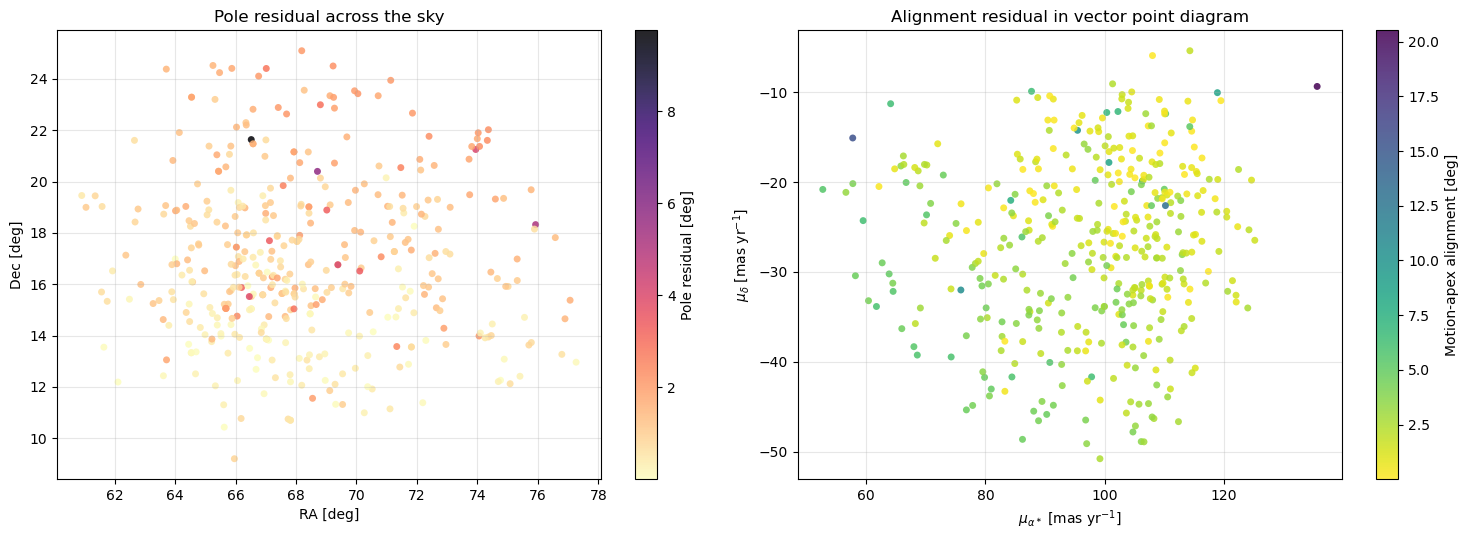

C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\src\utils.py:2462: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


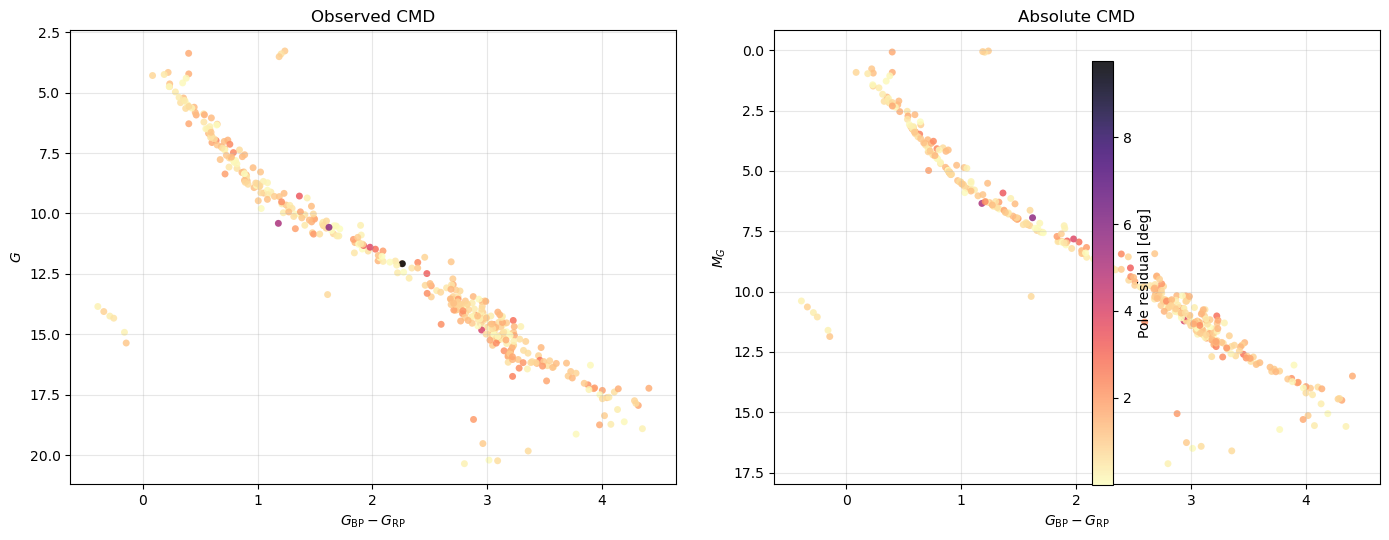


Returned objects
summary_df : global validation metrics
df_diag    : star-by-star diagnostic table
boot_df    : bootstrap apex table


In [63]:
summary_df, df_diag, boot_df = show_cluster_validation_products_icrs(
    result["cluster_result"],
    bootstrap_n=500,
)

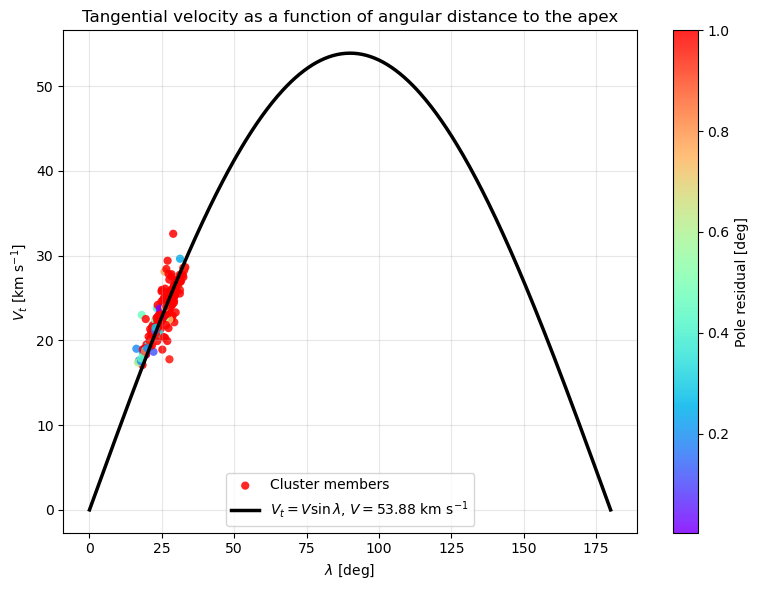

Fitted cluster speed from V_t = V sin(lambda): 53.875 km/s


In [64]:
# Datos
lambda_deg = df_diag["lambda_deg"].to_numpy(dtype=float)
vt_kms = df_diag["vt_kms"].to_numpy(dtype=float)
# residual = df_diag["pole_residual_deg"].to_numpy(dtype=float)
residual = df_diag["probabilidad"].to_numpy(dtype=float)

# Ajuste V_t = V sin(lambda)
lambda_rad = np.radians(lambda_deg)
sin_lambda = np.sin(lambda_rad)

valid = (
    np.isfinite(lambda_deg)
    & np.isfinite(vt_kms)
    & np.isfinite(sin_lambda)
    & (sin_lambda > 0)
)

x = sin_lambda[valid]
y = vt_kms[valid]

V_fit = np.sum(x * y) / np.sum(x * x)

# Curva teórica ajustada
lambda_grid_deg = np.linspace(0, 180, 500)
lambda_grid_rad = np.radians(lambda_grid_deg)
vt_model = V_fit * np.sin(lambda_grid_rad)

# Gráfica
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    lambda_deg,
    vt_kms,
    c=residual,
    s=35,
    cmap="rainbow",
    alpha=0.85,
    edgecolor="none",
    label="Cluster members",
)

plt.plot(
    lambda_grid_deg,
    vt_model,
    color="black",
    lw=2.5,
    label=rf"$V_t = V \sin\lambda$, $V = {V_fit:.2f}$ km s$^{{-1}}$",
)

plt.colorbar(sc, label="Pole residual [deg]")

plt.xlabel(r"$\lambda$ [deg]")
plt.ylabel(r"$V_t$ [km s$^{-1}$]")
plt.title(r"Tangential velocity as a function of angular distance to the apex")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fitted cluster speed from V_t = V sin(lambda): {V_fit:.3f} km/s")

In [65]:
def plot_pm_correction_diagnostics(
    df,
    pmra_col="pmra",
    pmdec_col="pmdec",
    pmra_corr_col="pmra_corrected_corr",
    pmdec_corr_col="pmdec_corrected_corr",
    figsize=(14, 10),
    bins=40,
    title_prefix="Proper-motion correction diagnostics"
):
    """
    Grafica diagnósticos de la corrección de movimientos propios.

    Paneles:
        1. Histograma de las diferencias:
              Delta pmra  = pmra_corr  - pmra
              Delta pmdec = pmdec_corr - pmdec

        2. Plano de movimientos propios:
              original vs corregido

        3. Histograma de pmra:
              pmra original vs pmra corregido

        4. Histograma de pmdec:
              pmdec original vs pmdec corregido
    """

    required = [
        pmra_col,
        pmdec_col,
        pmra_corr_col,
        pmdec_corr_col,
    ]

    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas necesarias: {missing}")

    data = df.copy()

    # Diferencias entre movimiento propio corregido y observado.
    data["d_pmra"] = data[pmra_corr_col] - data[pmra_col]
    data["d_pmdec"] = data[pmdec_corr_col] - data[pmdec_col]

    # Selección de datos válidos.
    mask = np.isfinite(data[pmra_col])
    mask &= np.isfinite(data[pmdec_col])
    mask &= np.isfinite(data[pmra_corr_col])
    mask &= np.isfinite(data[pmdec_corr_col])
    mask &= np.isfinite(data["d_pmra"])
    mask &= np.isfinite(data["d_pmdec"])

    data = data.loc[mask].copy()

    if len(data) == 0:
        raise ValueError("No hay datos válidos para graficar.")

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    ax1, ax2, ax3, ax4 = axes.ravel()

    # ------------------------------------------------------------
    # 1. Histograma de las diferencias
    # ------------------------------------------------------------
    ax1.hist(
        data["d_pmra"],
        bins=bins,
        alpha=0.65,
        label=r"$\Delta \mu_{\alpha *}$",
        color="tab:blue"
    )

    ax1.hist(
        data["d_pmdec"],
        bins=bins,
        alpha=0.65,
        label=r"$\Delta \mu_{\delta}$",
        color="tab:orange"
    )

    ax1.axvline(0, color="black", linestyle="--", linewidth=1)

    ax1.set_xlabel(r"$\Delta \mu$ [mas yr$^{-1}$]")
    ax1.set_ylabel("Number of stars")
    ax1.set_title("Correction distribution")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # ------------------------------------------------------------
    # 2. Plano de movimientos propios: original vs corregido
    # ------------------------------------------------------------
    ax2.scatter(
        data[pmra_col],
        data[pmdec_col],
        s=10,
        alpha=0.35,
        label="Observed",
        color="gray"
    )

    ax2.scatter(
        data[pmra_corr_col],
        data[pmdec_corr_col],
        s=10,
        alpha=0.35,
        label="Corrected",
        color="tab:red"
    )

    ax2.set_xlabel(r"$\mu_{\alpha *}$ [mas yr$^{-1}$]")
    ax2.set_ylabel(r"$\mu_{\delta}$ [mas yr$^{-1}$]")
    ax2.set_title("Proper-motion plane")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # ------------------------------------------------------------
    # 3. Histograma solo para movimiento propio en ascensión recta
    # ------------------------------------------------------------
    ax3.hist(
        data[pmra_col],
        bins=bins,
        alpha=0.6,
        label="Observed",
        color="gray"
    )

    ax3.hist(
        data[pmra_corr_col],
        bins=bins,
        alpha=0.6,
        label="Corrected",
        color="tab:blue"
    )

    ax3.axvline(
        np.nanmedian(data[pmra_col]),
        color="black",
        linestyle="--",
        linewidth=1,
        label="Observed median"
    )

    ax3.axvline(
        np.nanmedian(data[pmra_corr_col]),
        color="tab:blue",
        linestyle="--",
        linewidth=1,
        label="Corrected median"
    )

    ax3.set_xlabel(r"$\mu_{\alpha *}$ [mas yr$^{-1}$]")
    ax3.set_ylabel("Number of stars")
    ax3.set_title(r"Right ascension proper motion")
    ax3.legend()
    ax3.grid(alpha=0.3)

    # ------------------------------------------------------------
    # 4. Histograma solo para movimiento propio en declinación
    # ------------------------------------------------------------
    ax4.hist(
        data[pmdec_col],
        bins=bins,
        alpha=0.6,
        label="Observed",
        color="gray"
    )

    ax4.hist(
        data[pmdec_corr_col],
        bins=bins,
        alpha=0.6,
        label="Corrected",
        color="tab:orange"
    )

    ax4.axvline(
        np.nanmedian(data[pmdec_col]),
        color="black",
        linestyle="--",
        linewidth=1,
        label="Observed median"
    )

    ax4.axvline(
        np.nanmedian(data[pmdec_corr_col]),
        color="tab:orange",
        linestyle="--",
        linewidth=1,
        label="Corrected median"
    )

    ax4.set_xlabel(r"$\mu_{\delta}$ [mas yr$^{-1}$]")
    ax4.set_ylabel("Number of stars")
    ax4.set_title(r"Declination proper motion")
    ax4.legend()
    ax4.grid(alpha=0.3)

    fig.suptitle(title_prefix, fontsize=15)
    fig.tight_layout()

    plt.show()

    # ------------------------------------------------------------
    # Resumen numérico
    # ------------------------------------------------------------
    print("Number of valid stars:", len(data))
    print()
    print("Median pmra observed   [mas/yr]:", np.nanmedian(data[pmra_col]))
    print("Median pmra corrected  [mas/yr]:", np.nanmedian(data[pmra_corr_col]))
    print("Median d_pmra          [mas/yr]:", np.nanmedian(data["d_pmra"]))
    print()
    print("Median pmdec observed  [mas/yr]:", np.nanmedian(data[pmdec_col]))
    print("Median pmdec corrected [mas/yr]:", np.nanmedian(data[pmdec_corr_col]))
    print("Median d_pmdec         [mas/yr]:", np.nanmedian(data["d_pmdec"]))
    print()
    print("Mean d_pmra            [mas/yr]:", np.nanmean(data["d_pmra"]))
    print("Mean d_pmdec           [mas/yr]:", np.nanmean(data["d_pmdec"]))

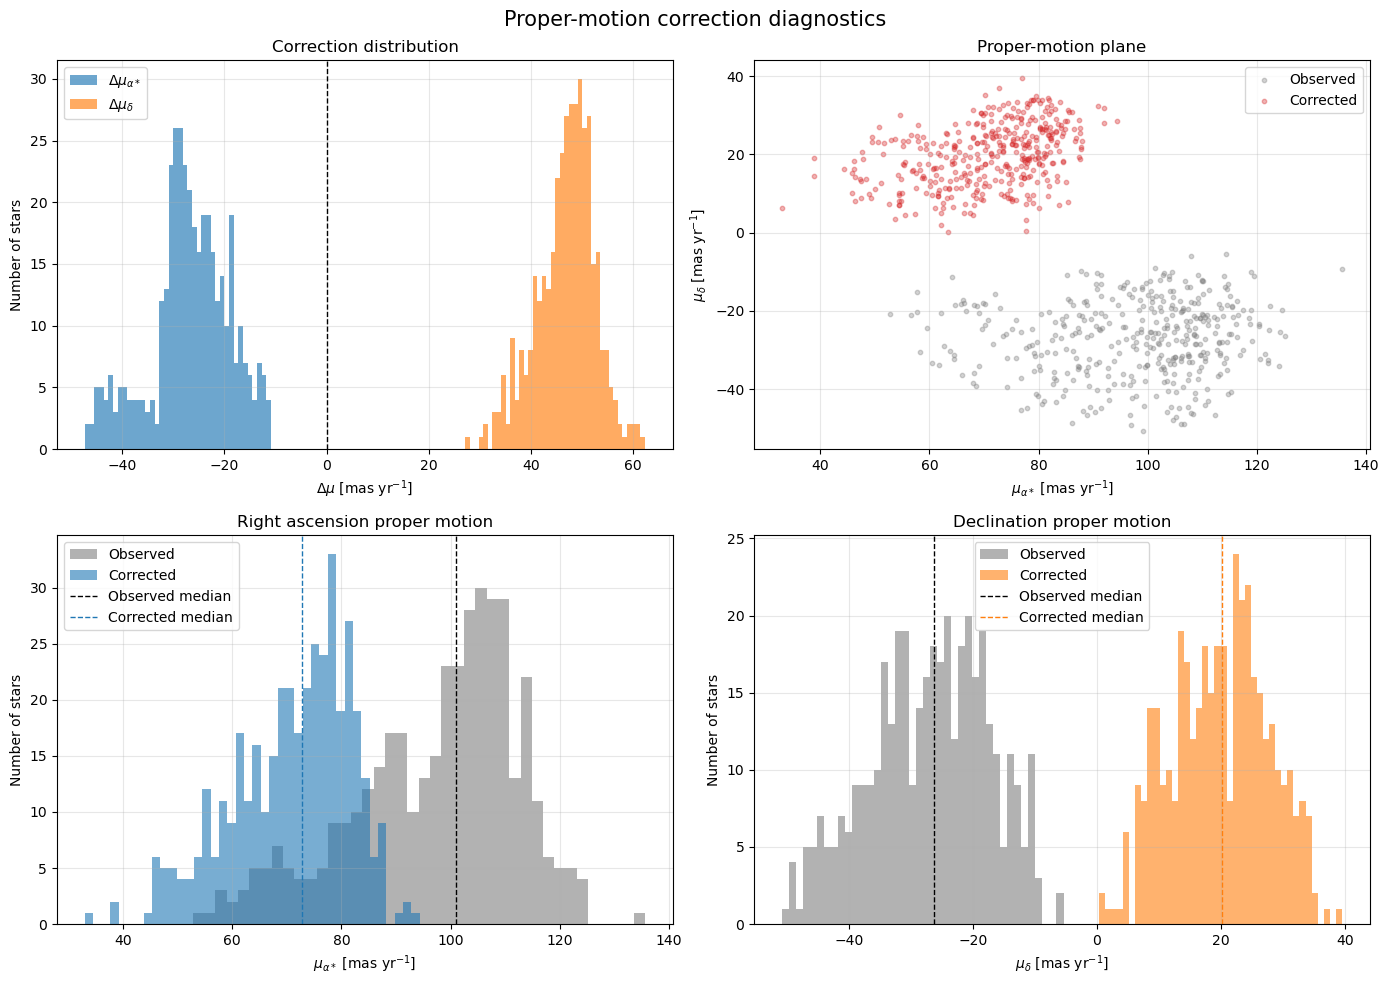

Number of valid stars: 400

Median pmra observed   [mas/yr]: 101.00854381363843
Median pmra corrected  [mas/yr]: 72.83785511099478
Median d_pmra          [mas/yr]: -26.538801372292667

Median pmdec observed  [mas/yr]: -26.2167444124395
Median pmdec corrected [mas/yr]: 20.070935355248963
Median d_pmdec         [mas/yr]: 47.5405856996325

Mean d_pmra            [mas/yr]: -26.650754441016364
Mean d_pmdec           [mas/yr]: 46.83075101867995


In [66]:
plot_pm_correction_diagnostics(df)